#  01. Low Router Confidence → Mode-Based Switching

**Theme**: When Router confidence is **low**, the Load Balancer uses the **mode** and **aggregated stats** to make smarter decisions.

## Key Insight
- **High Confidence** (>60%) → Trust Router's choice
- **Low Confidence** (<60%) → Consider alternatives based on mode (accuracy/cheap/fast/balanced)

---
## 1. Common Setup (Real Data)

In [1]:
import sys
from pathlib import Path
# Path setup
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
ARTEMIS_DIR = ROOT_DIR / 'artemis_final'
CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ARTEMIS_DIR))


In [2]:

# Imports
from sqlalchemy import create_engine, text
from artemis_final.load_balancer.public_api import (
    load_capacity_config,
    StatsRegistry,
    ArtemisLoadBalancer,
    RouterOutput,
    SchedulingContext,
    ModelCapacityConfig
)
from artemis_final.ares.configs.db_config import DB_URL, TABLES


In [3]:
DB_AVAILABLE = True

# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None


Device: mps


In [4]:
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    print(f" Looking for checkpoint at {ckpt_path}")
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

 Looking for checkpoint at /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: cpu
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [5]:
# Load samples from database
def load_samples(n=10):
    if not DB_AVAILABLE:
        return [{'sample_id': f'synth_{i}', 'prompt': f'Sample prompt {i}', 'router_task': 'vqa', 'image_bytes': None} for i in range(n)]
    try:
        engine = create_engine(DB_URL)
        with engine.connect() as conn:
            result = conn.execute(text(f"SELECT sample_id, prompt_text, router_task FROM {TABLES['samples']} WHERE prompt_text IS NOT NULL ORDER BY RANDOM() LIMIT {n}"))
            return [{'sample_id': r[0], 'prompt': r[1], 'router_task': r[2] or 'vqa'} for r in result.fetchall()]
    except Exception as e:
        print(f"️ DB Error: {e}")
        return [{'sample_id': f'fallback_{i}', 'prompt': f'Prompt {i}', 'router_task': 'vqa'} for i in range(n)]

samples = load_samples(10)
print(f" Loaded {len(samples)} samples")

 Loaded 10 samples


In [6]:
# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device=DEVICE)
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

Device: mps
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: mps
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
   Modes: ['accuracy', 'cheap', 'fast', 'balanced']


In [7]:
# Load Balancer with confidence threshold
try:
    model_configs = load_capacity_config()
except:
    model_configs = {
        'qwen2_5_vl_7b': ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, cost_per_request_usd=0.005),
        'gemma_3_27b': ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, cost_per_request_usd=0.01),
    }

lb = ArtemisLoadBalancer(
    model_configs=model_configs,
    stats_registry=StatsRegistry(),
    latency_sla_ms={'default': 3000},
    scheduling_mode='capacity_aware',
    router_confidence_threshold=0.6,  # Key threshold!
    simulation_only=False,
)

print(f" Load Balancer ready")
print(f"   Confidence threshold: 0.6 (60%)")

 Load Balancer ready
   Confidence threshold: 0.6 (60%)


In [ ]:

# === VLM Client Setup ===
from artemis_final.utils.vlm_client_factory import get_vlm_client

# Initialize Client
# simulation_only=False means we try to load real models from config.
# If config is missing or fails, it falls back to Mock.
# Note: In the notebooks below, specific simulation_only flags might override this intention for the Load Balancer,
# but we prepare the client here.
try:
    # Check if 'lb' exists and use its setting, otherwise default to False (Real)
    sim_mode = lb.simulation_only if 'lb' in locals() else False
    vlm_client = get_vlm_client(simulation_only=sim_mode)
    print(f" VLM Client initialized: {type(vlm_client).__name__}")
except Exception as e:
    print(f" Could not initialize VLM client: {e}")
    vlm_client = None


---
## 2. Experiment: Observe Confidence Impact

In [8]:
results = []
import time
for sample in samples:
    # Get router prediction
    if router:
        try:
            rr = router.route(prompt=sample['prompt'], mode='balanced', metadata={'router_task': sample['router_task']})
            probs = get_router_probs(rr)
            preferred = rr['chosen_model']
            confidence = probs.get(preferred, 0)
        except Exception as e:
            probs = {list(model_configs.keys())[0]: 0.5}
            preferred = list(model_configs.keys())[0]
            confidence = 0.5
    else:
        # Synthetic varying confidence
        import random
        confidence = random.uniform(0.3, 0.9)
        models = list(model_configs.keys())
        preferred = random.choice(models)
        probs = {m: (confidence if m == preferred else (1-confidence)/(len(models)-1)) for m in models}
    
    # Schedule through LB
    ro = RouterOutput(
        sample_id=sample['sample_id'], task_type=sample['router_task'],
        router_probs=probs, preferred_model=preferred, max_prob=confidence
    )
    ctx = SchedulingContext(arrival_ts_ms=time.time()*1000, load_profile='test')
    dec = lb.schedule(ro, ctx)
    # === VLM Inference (Injected) ===
    if 'call_vlm' in locals() and call_vlm and vlm_client:
        # Try to get image data
        img_data = sample.get('image_bytes') or sample.get('image')
        if img_data:
            try:
                # If bytes, convert to PIL or pass as is (Client handles it)
                from io import BytesIO
                from PIL import Image
                if isinstance(img_data, bytes):
                    img_input = Image.open(BytesIO(img_data))
                else:
                    img_input = img_data
                    
                print(f"   Invoking VLM ({dec.chosen_model})...")
                vlm_result = vlm_client.vlm.run_image(
                    image=img_input,
                    text=sample['prompt'],
                    models=[dec.chosen_model],
                    max_tokens=200
                )
                
                # Extract result
                model_resp = vlm_result.get(dec.chosen_model, {})
                if model_resp.get('ok'):
                    print(f"   VLM Response: {model_resp.get('response_text')[:100]}...")
                else:
                    print(f"   VLM Error: {model_resp.get('error')}")
                    
            except Exception as e:
                print(f"   VLM call failed: {e}")
        else:
           pass # No image data for VLM


    
    results.append({
        'sample_id': sample['sample_id'],
        'confidence': confidence,
        'conf_level': 'HIGH' if confidence >= 0.6 else 'LOW',
        'router_choice': preferred,
        'lb_choice': dec.chosen_model,
        'agreed': preferred == dec.chosen_model,
        'latency_ms': dec.total_latency_ms,
    })
    
    print(f"{sample['sample_id']}: Conf={confidence:.0%} ({'HIGH' if confidence >= 0.6 else 'LOW'}) | "
          f"Router={preferred} → LB={dec.chosen_model} | {'' if preferred == dec.chosen_model else ''}")

robut_sqa_460_b2fd4e8f: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
hateful_memes_694_80da3d2d: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
datikz_209_ddeebc59: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
ai2d_854_b02548f5: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
robut_sqa_541_d3c63434: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
visual7w_372_b2c160ff: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
geomverse_179_00d02ac6: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
visual7w_489_06609f6e: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
plotqa_305_04c38b59: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 
localized_narratives_259_1515ca22: Conf=50% (LOW) | Router=gemma_3_27b → LB=gemma_3_27b | 


In [9]:
import pandas as pd
df = pd.DataFrame(results)
print("\n Results Summary:")
display(df)


 Results Summary:


,sample_id,confidence,conf_level,router_choice,lb_choice,agreed,latency_ms
0,robut_sqa_460_b2fd4e8f,0.5,LOW,gemma_3_27b,gemma_3_27b,True,4522.730164
1,hateful_memes_694_80da3d2d,0.5,LOW,gemma_3_27b,gemma_3_27b,True,3501.820204
2,datikz_209_ddeebc59,0.5,LOW,gemma_3_27b,gemma_3_27b,True,29591.614156
3,ai2d_854_b02548f5,0.5,LOW,gemma_3_27b,gemma_3_27b,True,5429.333357
4,robut_sqa_541_d3c63434,0.5,LOW,gemma_3_27b,gemma_3_27b,True,9930.742371
5,visual7w_372_b2c160ff,0.5,LOW,gemma_3_27b,gemma_3_27b,True,10981.867412
6,geomverse_179_00d02ac6,0.5,LOW,gemma_3_27b,gemma_3_27b,True,27276.309751
7,visual7w_489_06609f6e,0.5,LOW,gemma_3_27b,gemma_3_27b,True,28325.994365
8,plotqa_305_04c38b59,0.5,LOW,gemma_3_27b,gemma_3_27b,True,28840.072433
9,localized_narratives_259_1515ca22,0.5,LOW,gemma_3_27b,gemma_3_27b,True,31657.144070


---
## 3. Visualization: Agreement by Confidence Level

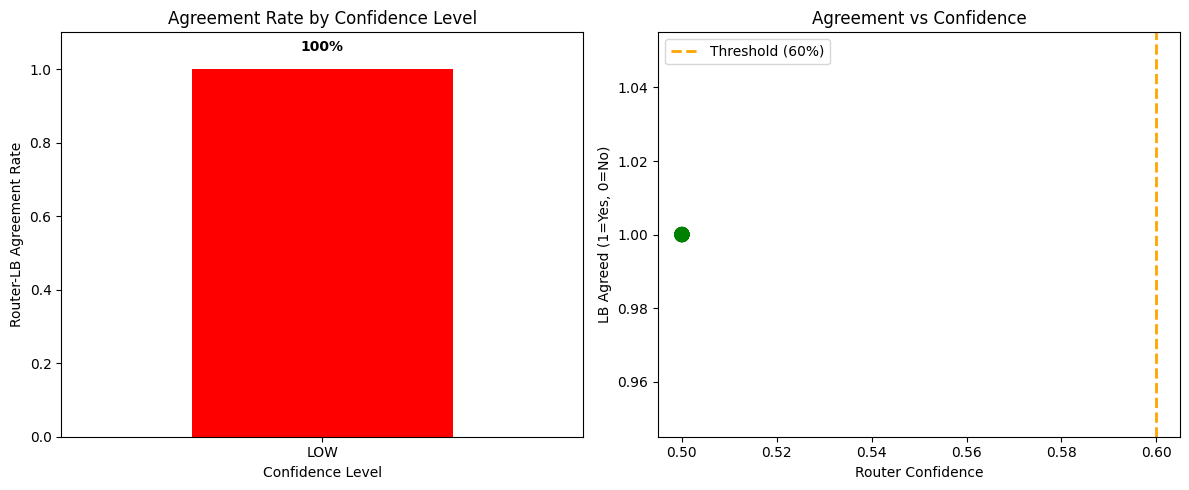


 Insight: When confidence is LOW, LB may consider mode-based alternatives.
   When confidence is HIGH, LB trusts the Router's recommendation.


In [10]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Agreement rate by confidence level
ax1 = axes[0]
agreement_by_level = df.groupby('conf_level')['agreed'].mean()
colors = ['red' if l == 'LOW' else 'green' for l in agreement_by_level.index]
agreement_by_level.plot(kind='bar', ax=ax1, color=colors)
ax1.set_xlabel('Confidence Level')
ax1.set_ylabel('Router-LB Agreement Rate')
ax1.set_title('Agreement Rate by Confidence Level')
ax1.set_ylim(0, 1.1)
ax1.tick_params(axis='x', rotation=0)

for i, v in enumerate(agreement_by_level):
    ax1.text(i, v + 0.05, f'{v:.0%}', ha='center', fontweight='bold')

# Plot 2: Scatter of confidence vs agreement
ax2 = axes[1]
colors = ['green' if a else 'red' for a in df['agreed']]
ax2.scatter(df['confidence'], [1 if a else 0 for a in df['agreed']], c=colors, s=100, alpha=0.7)
ax2.axvline(x=0.6, color='orange', linestyle='--', linewidth=2, label='Threshold (60%)')
ax2.set_xlabel('Router Confidence')
ax2.set_ylabel('LB Agreed (1=Yes, 0=No)')
ax2.set_title('Agreement vs Confidence')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n Insight: When confidence is LOW, LB may consider mode-based alternatives.")
print("   When confidence is HIGH, LB trusts the Router's recommendation.")

---
## Summary

This notebook demonstrated:
- **High confidence** → LB trusts Router
- **Low confidence** → LB may switch based on mode and stats
- The confidence threshold (60% default) controls this behavior